In [11]:
import pandas as pd

df = pd.read_csv("heart_failure_clinical_records_dataset.csv")
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [12]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000


The dataset contains clinical records of heart failure patients, including demographic and laboratory features. There are no missing values observed, and all variables are either numerical or binary, making the dataset suitable for machine learning analysis.

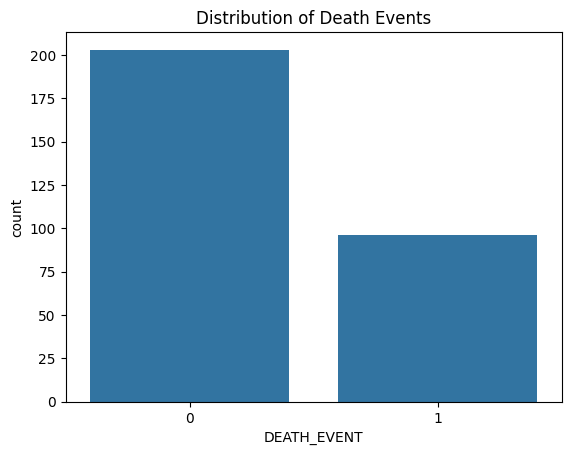

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='DEATH_EVENT', data=df)
plt.title("Distribution of Death Events")
plt.show()

### Distribution of Death Events

The plot shows the distribution of the target variable (DEATH_EVENT). 
It can be observed that the number of patients who survived (0) is higher than those who died (1).

This indicates that the dataset is slightly imbalanced, with more survival cases than death cases. 
Such imbalance should be considered when building predictive models, as it may affect model performance.

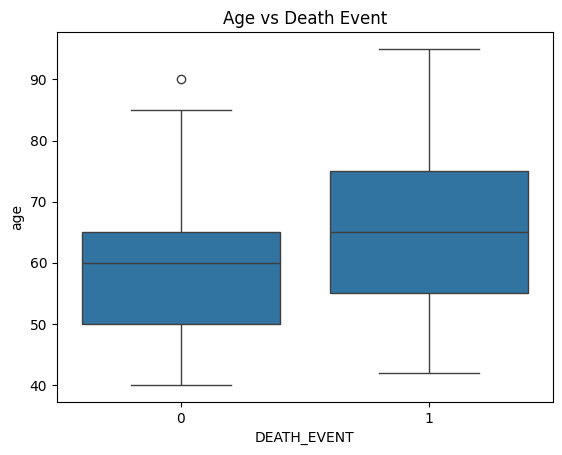

In [14]:
sns.boxplot(x='DEATH_EVENT', y='age', data=df)
plt.title("Age vs Death Event")
plt.show()

### Age vs Death Event

The boxplot shows the relationship between age and the death event. 
It can be observed that patients who died (1) tend to have higher ages compared to those who survived (0).

The median age of the death group is noticeably higher, and the distribution is shifted upward. 
This suggests that older patients have a higher risk of death, indicating that age is an important factor in predicting heart failure outcomes.

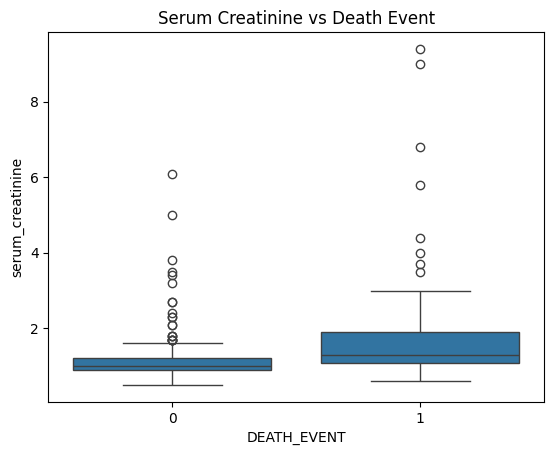

In [15]:

sns.boxplot(x='DEATH_EVENT', y='serum_creatinine', data=df)
plt.title("Serum Creatinine vs Death Event")
plt.show()

### Serum Creatinine vs Death Event

The boxplot shows the relationship between serum creatinine levels and the death event. 
It can be observed that patients who died (1) tend to have higher serum creatinine levels compared to those who survived (0).

The distribution of the death group is shifted upward, with a higher median and more extreme values. 
This suggests that impaired kidney function is associated with a higher risk of death.

Therefore, serum creatinine appears to be an important predictor for heart failure outcomes.

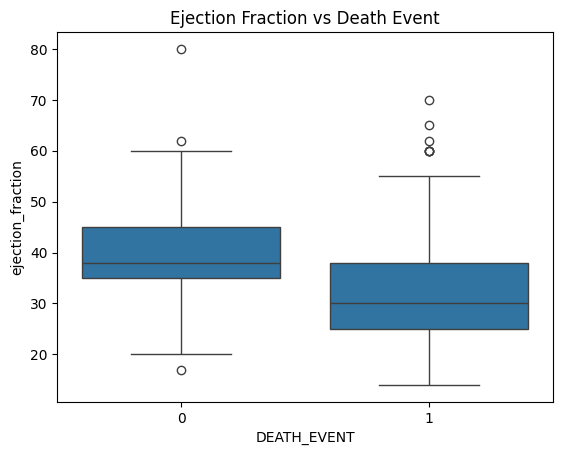

In [16]:
#心脏功能
sns.boxplot(x='DEATH_EVENT', y='ejection_fraction', data=df)
plt.title("Ejection Fraction vs Death Event")
plt.show()

### Ejection Fraction vs Death Event
#### 死亡的人 -> 心脏功能更差 -> ejection fraction更低 

The boxplot illustrates the relationship between ejection fraction and the death event. 
It can be clearly observed that patients who died (1) tend to have lower ejection fraction values compared to those who survived (0).

The median ejection fraction for the death group is significantly lower, and the overall distribution is shifted downward. 
This indicates that reduced heart pumping function is strongly associated with a higher risk of death.

Therefore, ejection fraction is a critical feature for predicting heart failure outcomes.

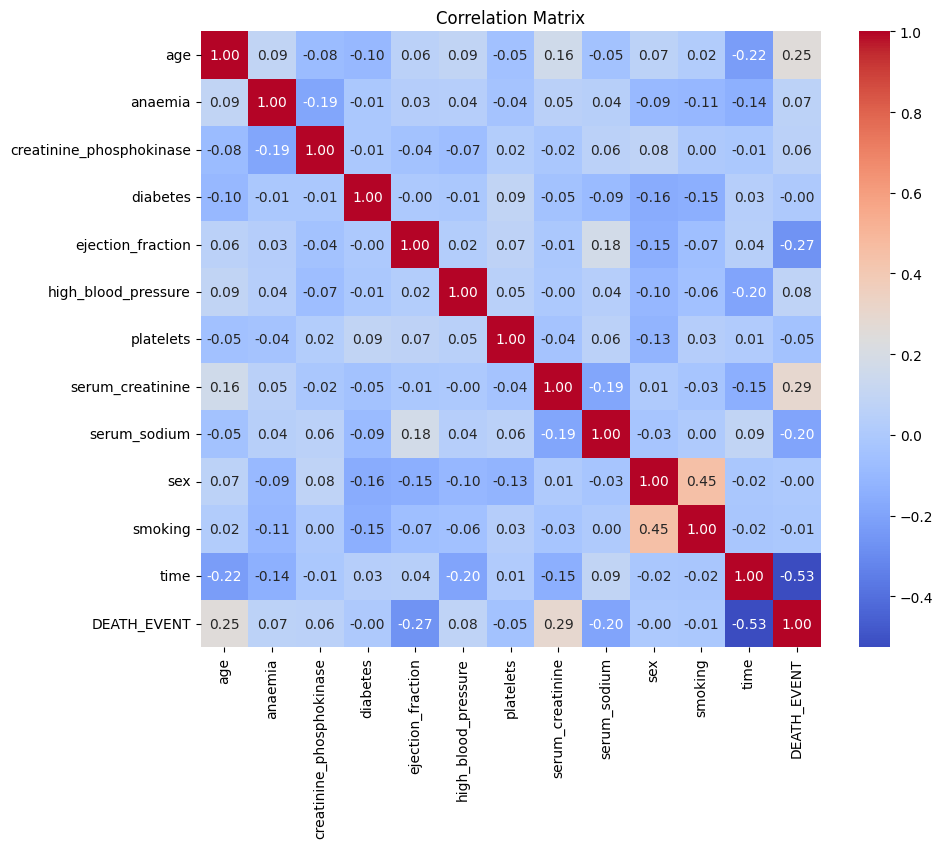

In [17]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


=== anaemia vs DEATH_EVENT ===
DEATH_EVENT         0         1
anaemia                        
0            0.705882  0.294118
1            0.643411  0.356589

=== diabetes vs DEATH_EVENT ===
DEATH_EVENT         0         1
diabetes                       
0            0.678161  0.321839
1            0.680000  0.320000

=== high_blood_pressure vs DEATH_EVENT ===
DEATH_EVENT                 0         1
high_blood_pressure                    
0                    0.706186  0.293814
1                    0.628571  0.371429

=== smoking vs DEATH_EVENT ===
DEATH_EVENT         0         1
smoking                        
0            0.674877  0.325123
1            0.687500  0.312500


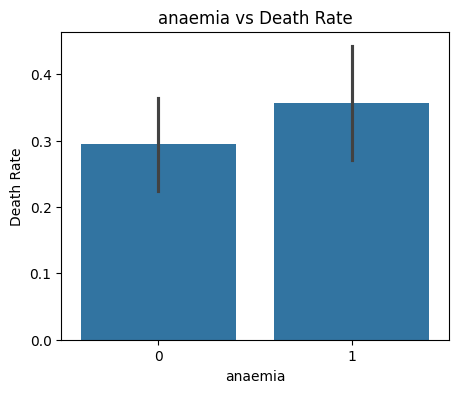

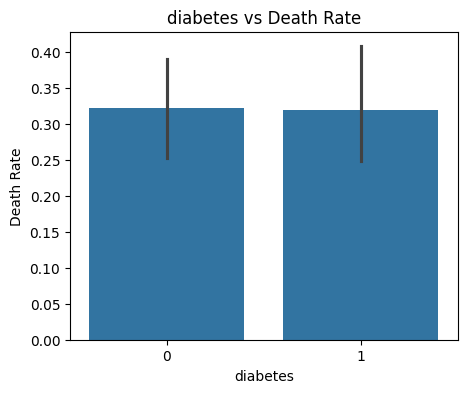

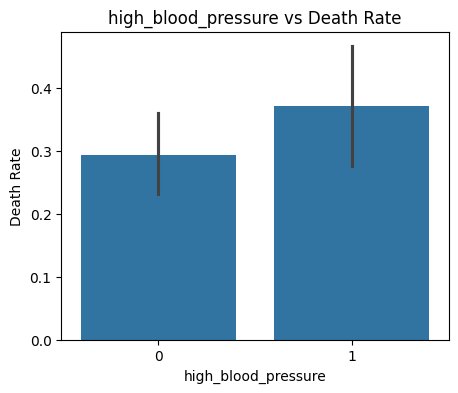

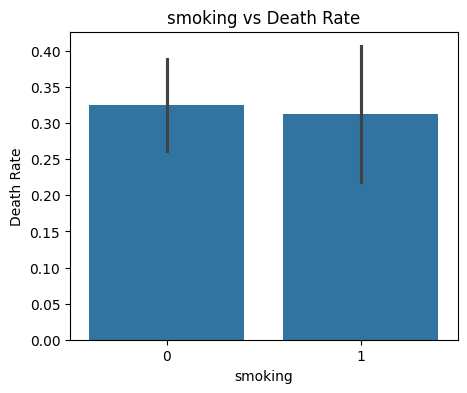

In [18]:
#疾病和生活习惯的变量分析
#用来比较不同种疾病的发生是否影响death event
#binary features
disease_cols = ["anaemia", "diabetes", "high_blood_pressure", "smoking"]

for col in disease_cols:
    print(f"\n=== {col} vs DEATH_EVENT ===")
    print(pd.crosstab(df[col], df["DEATH_EVENT"], normalize="index"))

#plot
for col in disease_cols:
    plt.figure(figsize=(5,4))
    sns.barplot(x=col, y="DEATH_EVENT", data=df)
    plt.title(f"{col} vs Death Rate")
    plt.xlabel(col)
    plt.ylabel("Death Rate")
    plt.show()

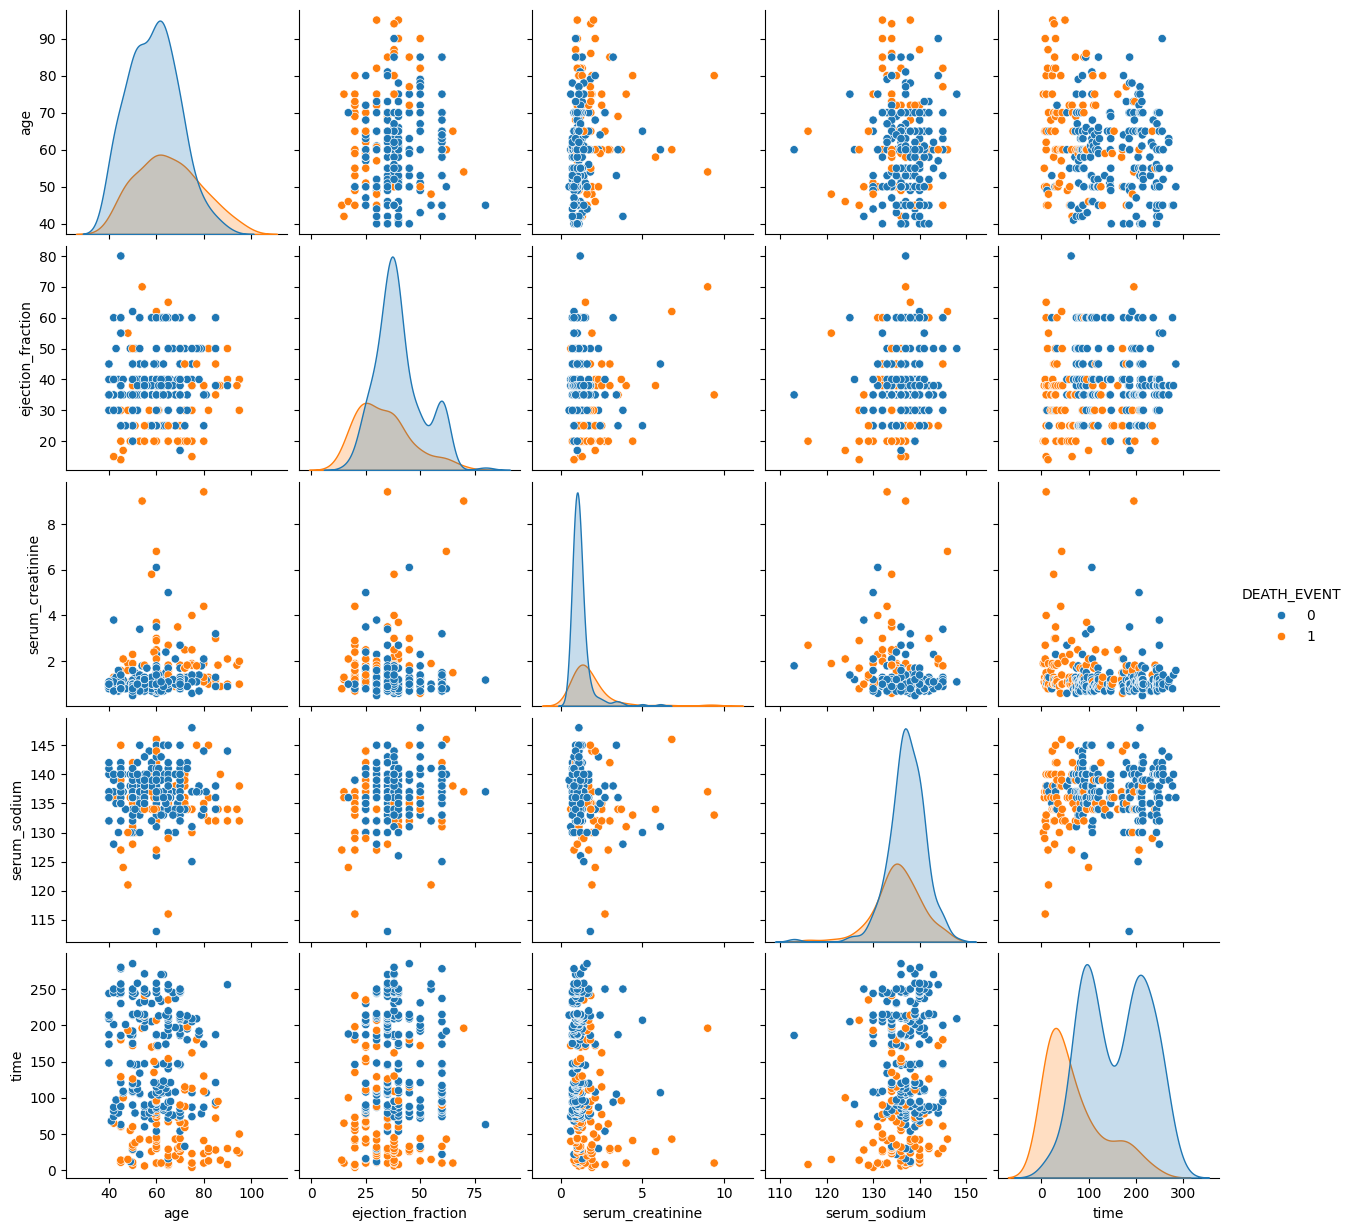

In [19]:
import seaborn as sns

selected_cols = [
    "age",
    "ejection_fraction",
    "serum_creatinine",
    "serum_sodium",
    "time",
    "DEATH_EVENT"
]

sns.pairplot(
    df[selected_cols],
    hue="DEATH_EVENT"
)

plt.show()

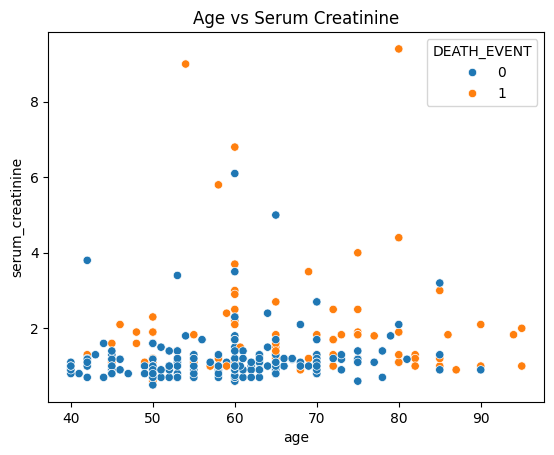

In [20]:
#scatterplot
sns.scatterplot(
    x="age",
    y="serum_creatinine",
    hue="DEATH_EVENT",
    data=df
)

plt.title("Age vs Serum Creatinine")
plt.show()

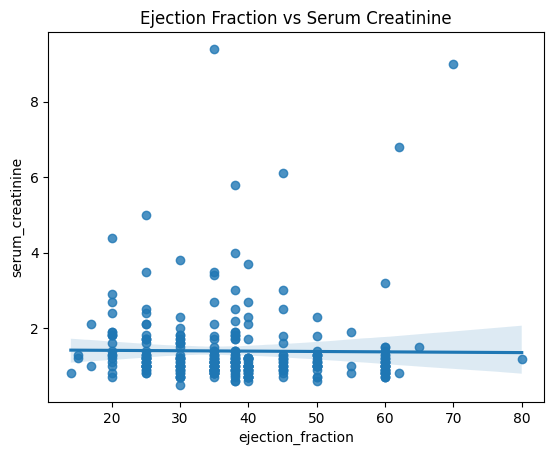

In [22]:
sns.regplot(
    x="ejection_fraction",
    y="serum_creatinine",
    data=df
)

plt.title("Ejection Fraction vs Serum Creatinine")
plt.show()

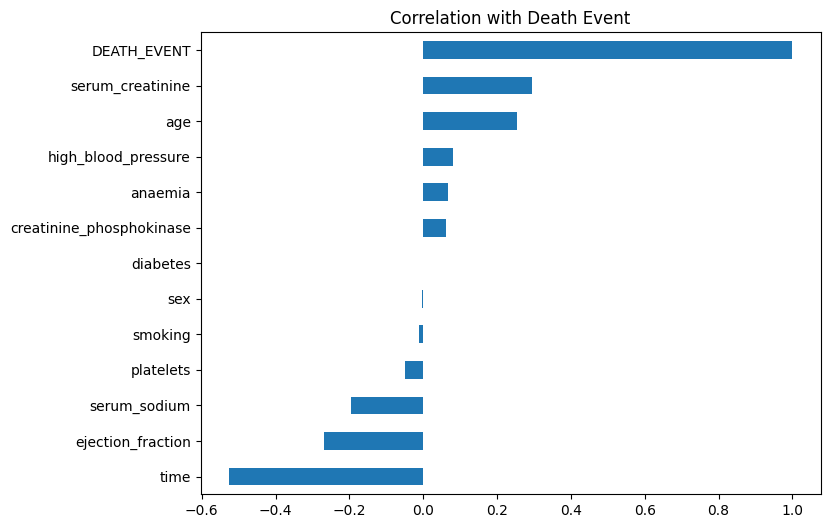

In [23]:
corr_target = df.corr()["DEATH_EVENT"].sort_values()

plt.figure(figsize=(8,6))
corr_target.plot(kind="barh")

plt.title("Correlation with Death Event")
plt.show()

In [21]:
#不同death group的平均值对比
df.groupby("DEATH_EVENT").mean()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time
DEATH_EVENT,,,,,,,,,,,,
0,58.761906,0.408867,540.054187,0.418719,40.26601,0.325123,266657.489901,1.184877,137.216749,0.650246,0.325123,158.339901
1,65.215281,0.479167,670.197917,0.416667,33.46875,0.406250,256381.044792,1.835833,135.375000,0.645833,0.312500,70.885417


EDA provides essential insights into the relationships between clinical features and mortality, which helps guide model selection and interpretation.